# Introduction to HiDimStat

In this notebook, we will learn how to use several standard methods for assessing variable importance with HiDimStat.

Specifically, we will explore:

- Permutation Feature Importance (PFI)
- Conditional Feature Importance (CFI)
- Leave-One-Covariate-Out (LOCO)

We will illustrate these methods using the diabetes dataset.

In [1]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target
seed = 0
# Encode sex as binary
X[:, 1] = (X[:, 1] > 0.0).astype(int)
print(f"Number of samples: {X.shape[0]}, number of features: {X.shape[1]}")

Number of samples: 442, number of features: 10


## Need for Model-Agnostic Approaches

The main motivation for using variable importance measures is that they can be applied to complex predictive models without requiring access to their internal structure. This allows us to interpret highly flexible machine learning models while retaining their predictive performance.

In contrast, relying only on simple linear models provides direct interpretability, but may fail to capture complex relationships in the data and therefore offer a less accurate representation of the underlying distribution.

Model-agnostic variable importance methods, such as PFI, CFI, and LOCO, help bridge this gap by providing interpretable insights into feature importance regardless of the model being used.

In [2]:
import numpy as np
from sklearn.base import clone
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
)
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold

n_folds = 5
cv = KFold(n_splits=n_folds, shuffle=True, random_state=0)
regressor = VotingRegressor(
    [
        ("ridge", RidgeCV()),
        ("hgb", HistGradientBoostingRegressor()),
        ("rf", RandomForestRegressor()),
        ("lasso", LassoCV()),
    ]
)

scores = []
regressor_list = [clone(regressor) for _ in range(n_folds)]
for i, (train_index, test_index) in enumerate(cv.split(X)):
    regressor_list[i].fit(X[train_index], y[train_index])
    scores.append(
        r2_score(
            y_true=y[test_index],
            y_pred=regressor_list[i].predict(X[test_index]),
        )
    )
print(f"R2 scores across folds: {np.mean(scores):.3f} ± {np.std(scores):.3f}")
regressor

R2 scores across folds: 0.483 ± 0.094


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('ridge', ...), ('hgb', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.","(0.1, ...)"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",None
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : use 'svd' if n_samples > n_features, otherwise use 'eigen' 'svd' : force use of singular value decomposition of X when X is dense, eigenvalue decomposition of X^T.X when X is sparse. 'eigen' : force computation via eigendecomposition of X.X^TThe 'auto' mode is the default and is intended to pick the cheaperoption of the two depending on the shape of the training data.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation values corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False
,"alpha_per_target alpha_per_target: bool, default=FalseFlag indicating whether to optimize the alpha value (picked from the`alphas` parameter list) for each target separately (for multi-outputsettings: multiple prediction targets). When set to

### Train-test split

Note that a train–test split is necessary because complex learners can overfit the training data. Consequently, evaluating model performance on the same data used for training is not informative for assessing the true importance of a feature.

In [3]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=seed,
    shuffle=True,
)


regressor = regressor.fit(X_train, y_train)

### Permutation Feature Importance

In [4]:
from hidimstat import PFI

pfi = PFI(regressor)
pfi.fit(X_train, y_train)
importance_pfi = pfi.importance(X_test, y_test)

### Conditional Feature Importance

In [5]:
from hidimstat import CFI

cfi = CFI(regressor)
cfi.fit(X_train, y_train)
importance_cfi = cfi.importance(X_test, y_test)

/home/areyerol/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/home/areyerol/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


### Leave One Covariate Out

In [6]:
from hidimstat import LOCO

loco = LOCO(regressor)
loco.fit(X_train, y_train)
importance_loco = loco.importance(X_test, y_test)

### Visualization of the different Variable Importance Measures

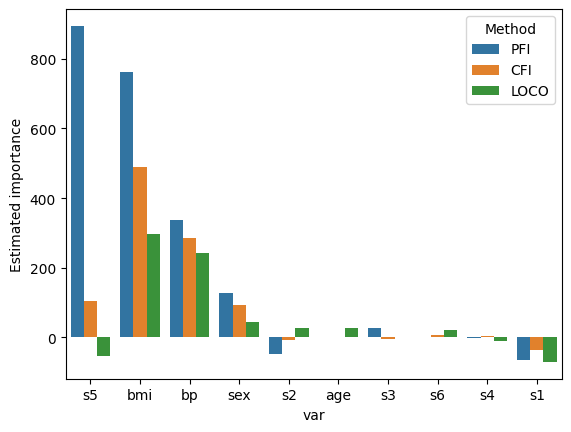

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df_plot = pd.concat(
    [
        pd.DataFrame(
            {
                "var": diabetes.feature_names,
                "importance": vim.importance(X_test, y_test),
                "method": vim_name,
            }
        )
        for vim, vim_name in zip(
            [pfi, cfi, loco],
            ["PFI", "CFI", "LOCO"],
            strict=False,
        )
    ]
)
df_plot = df_plot.sort_values("importance", ascending=False)

_, ax = plt.subplots()
sns.barplot(
    data=df_plot,
    x="var",
    y="importance",
    hue="method",
    ax=ax,
)
ax.set_ylabel(r"Estimated importance")
ax.legend(title="Method")

## Derandomizing with Cross-Validation

It is also possible to reduce the randomness introduced by a single train–test split by using cross-validation. In this approach, the procedure is repeated across multiple folds, and the results are aggregated to obtain more stable estimates of variable importance.

In [8]:
from hidimstat import PFICV

pfi_cv = PFICV(
    estimators=regressor_list,
    cv=cv,
    n_jobs=5,
    random_state=0,
)
importances_pfi = pfi_cv.fit_importance(X, y)

Fitting importance estimators for each fold: 100%|██████████| 5/5 [00:00<00:00, 191.31it/s]
/home/areyerol/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/areyerol/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/home/areyerol/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/areyerol/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottlen

In [9]:
from hidimstat import CFICV

cfi_cv = CFICV(
    estimators=regressor_list,
    cv=cv,
    n_jobs=5,
    random_state=0,
)
importances_cfi = cfi_cv.fit_importance(X, y)

Fitting importance estimators for each fold: 100%|██████████| 5/5 [00:00<00:00, 1724.92it/s]
/home/areyerol/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/home/areyerol/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring

In [10]:
from hidimstat import LOCOCV

loco_cv = LOCOCV(
    estimators=regressor_list,
    cv=cv,
    n_jobs=5,
)
importances_loco = loco_cv.fit_importance(X, y)

Computing importance scores over folds: 100%|██████████| 5/5 [00:00<00:00, 2366.99it/s]


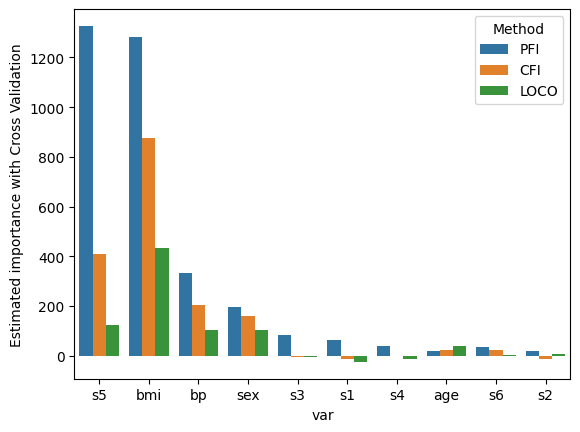

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df_plot = pd.concat(
    [
        pd.DataFrame(
            {
                "var": diabetes.feature_names,
                "importance": vim.importances_.mean(axis=1),
                "method": vim_name,
            }
        )
        for vim, vim_name in zip(
            [cfi_cv, loco_cv, pfi_cv],
            ["CFI", "LOCO", "PFI"],
            strict=False,
        )
    ]
)
df_plot = df_plot.sort_values("importance", ascending=False)

_, ax = plt.subplots()
sns.barplot(
    data=df_plot,
    x="var",
    y="importance",
    hue="method",
    ax=ax,
)
ax.set_ylabel(r"Estimated importance with Cross Validation")
ax.legend(title="Method")

Many additional analyses can be performed using HiDimStat. For example, when dealing with highly correlated features, it is possible to **group** variables to improve interpretability.

Beyond feature importance, HiDimStat also supports:

- p-values for conditional independence testing  
- Conditional Randomization Tests (CRT)  
- Control of the False Discovery Rate (FDR) using Model-X Knockoffs  

For more, see https://hidimstat.github.io.